In [ ]:
!unzip Dataset.zip -d /content/Dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0030.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0031.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0032.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0033.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0034.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0035.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0036.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0037.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0038.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0039.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0040.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0041.jpg  
  inflating: /content/Dataset/caltech-101/ceiling_fan/image_0042.jpg  
  inflating: /content/Data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.7 MB/s eta 0:00:00
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Embeddings: 58/60 images

📘 MobileNetV3 + LDA 5-fold CV:
 Accuracy: 0.9078
Precision: 0.9714
   Recall: 0.8955
       F1: 0.9282
  ROC-AUC: 0.9906
      FPR: 0.0667
      FNR: 0.1045


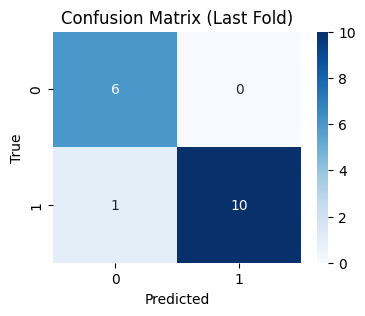

In [ ]:
!pip install mtcnn tensorflow

import os, glob, numpy as np, cv2
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import random

from mtcnn.mtcnn import MTCNN
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# ======================
# Face detection & embedding
# ======================
detector = MTCNN()

def extract_face(path, size=(224,224)):
    img = cv2.imread(path)
    if img is None: return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)
    if not results: return None
    x, y, w, h = results[0]['box']
    x, y = max(0,x), max(0,y)
    face = img_rgb[y:y+h, x:x+w]
    face = cv2.resize(face, size)
    return face

def get_embedding(model, path):
    face = extract_face(path)
    if face is None: return None
    arr = img_to_array(face)
    arr = np.expand_dims(arr,0)
    arr = preprocess_input(arr)
    return model.predict(arr,verbose=0).flatten()

def compute_embeddings(model, paths):
    emb_dict = {}
    for p in paths:
        emb = get_embedding(model,p)
        if emb is not None: emb_dict[p] = emb
    print(f"Embeddings: {len(emb_dict)}/{len(paths)} images")
    return emb_dict

def make_pair_feature(e1,e2):
    return np.concatenate([np.abs(e1-e2), e1*e2])

# ======================
# Prepare dataset pairs
# ======================
face_dir1 = '/content/Dataset/caltech-101/Faces'
face_dir2 = '/content/Dataset/caltech-101/Faces_easy'

imgs1 = glob.glob(face_dir1+'/*.jpg')
imgs2 = glob.glob(face_dir2+'/*.jpg')

# Positive: same image repeated (for small dataset demo)
pos_pairs = [(img,img) for img in imgs1[:30]] + [(img,img) for img in imgs2[:30]]
neg_pairs = [(imgs1[i], imgs2[i]) for i in range(min(len(imgs1),len(imgs2),30))]

pairs = pos_pairs + neg_pairs
labels = [1]*len(pos_pairs) + [0]*len(neg_pairs)

# Shuffle
data = list(zip(pairs, labels))
random.seed(42)
random.shuffle(data)
pairs, labels = zip(*data)
pairs, labels = list(pairs), list(labels)

# ======================
# Load model
# ======================
model_v3 = MobileNetV3Large(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))

# ======================
# Cross-validation
# ======================
def extract_fpr_fnr(cm):
    tn,fp,fn,tp = cm.ravel()
    return fp/(fp+tn), fn/(fn+tp)

def eval_fold(train_pairs,train_labels,test_pairs,test_labels,emb_dict):
    X_train = np.array([make_pair_feature(emb_dict[a],emb_dict[b]) for (a,b) in train_pairs if a in emb_dict and b in emb_dict])
    y_train = np.array([lbl for (a,b),lbl in zip(train_pairs,train_labels) if a in emb_dict and b in emb_dict])
    X_test = np.array([make_pair_feature(emb_dict[a],emb_dict[b]) for (a,b) in test_pairs if a in emb_dict and b in emb_dict])
    y_test = np.array([lbl for (a,b),lbl in zip(test_pairs,test_labels) if a in emb_dict and b in emb_dict])

    if len(y_train)<2 or len(y_test)==0: return [np.nan]*7 + [np.zeros((2,2))]

    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    lda = LDA(n_components=1)
    X_train_proj = lda.fit_transform(X_train,y_train)
    X_test_proj = lda.transform(X_test)
    train_scores = X_train_proj[:,0]
    test_scores = X_test_proj[:,0]

    fpr_t, tpr_t, thr = roc_curve(y_train,train_scores)
    best_thr = thr[np.argmax(tpr_t - fpr_t)]
    y_pred = (test_scores>=best_thr).astype(int)

    acc  = accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,y_pred,zero_division=0)
    rec  = recall_score(y_test,y_pred,zero_division=0)
    f1   = f1_score(y_test,y_pred,zero_division=0)
    auc  = roc_auc_score(y_test,test_scores)
    cm   = confusion_matrix(y_test,y_pred)
    fpr, fnr = extract_fpr_fnr(cm)

    return acc,prec,rec,f1,auc,fpr,fnr,cm

def crossval_pipeline(pairs,labels,model,n_splits=5):
    pairs = np.array(pairs)
    labels = np.array(labels)
    skf = StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=42)
    all_imgs = list({img for pair in pairs for img in pair})
    emb_dict = compute_embeddings(model,all_imgs)
    results = []
    cm_final = None
    for fold,(train_idx,test_idx) in enumerate(skf.split(pairs,labels),1):
        train_pairs,test_pairs = pairs[train_idx], pairs[test_idx]
        train_labels,test_labels = labels[train_idx], labels[test_idx]
        acc,prec,rec,f1,auc,fpr,fnr,cm = eval_fold(train_pairs,train_labels,test_pairs,test_labels,emb_dict)
        results.append((acc,prec,rec,f1,auc,fpr,fnr))
        if fold==n_splits: cm_final=cm

    results = np.array(results,dtype=float)
    print("\n📘 MobileNetV3 + LDA 5-fold CV:")
    metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC','FPR','FNR']
    for i,name in enumerate(metrics):
        print(f"{name:>9}: {np.nanmean(results[:,i]):.4f}")

    if cm_final is not None:
        plt.figure(figsize=(4,3))
        sns.heatmap(cm_final,annot=True,fmt='d',cmap='Blues')
        plt.title('Confusion Matrix (Last Fold)')
        plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

    return results

# ======================
# Run evaluation
# ======================
results_v3 = crossval_pipeline(pairs,labels,model_v3)


In [ ]:
# Install required packages
!pip install mtcnn tensorflow scikit-fuzzy minisom -q

import os, glob, numpy as np, cv2
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

from mtcnn.mtcnn import MTCNN
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Initialize
detector = MTCNN()

def extract_face(path, size=(224,224)):
    img = cv2.imread(path)
    if img is None: return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)
    if not results: return None
    x, y, w, h = results[0]['box']
    x, y = max(0,x), max(0,y)
    face = img_rgb[y:y+h, x:x+w]
    face = cv2.resize(face, size)
    return face

def get_embedding(model, path):
    face = extract_face(path)
    if face is None: return None
    arr = img_to_array(face)
    arr = np.expand_dims(arr,0)
    arr = preprocess_input(arr)
    return model.predict(arr,verbose=0).flatten()

def compute_embeddings(model, paths):
    emb_dict = {}
    for p in paths:
        emb = get_embedding(model,p)
        if emb is not None: emb_dict[p] = emb
    print(f"✅ Embeddings: {len(emb_dict)}/{len(paths)} images")
    return emb_dict

def save_clusters_to_folders(emb_dict, labels, output_dir, algorithm_name):
    """Save clustered images to organized folders"""
    base_dir = os.path.join(output_dir, algorithm_name)
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
    os.makedirs(base_dir, exist_ok=True)

    paths = list(emb_dict.keys())
    unique_labels = np.unique(labels)

    for label in unique_labels:
        if label == -1:
            cluster_dir = os.path.join(base_dir, 'outliers')
        else:
            cluster_dir = os.path.join(base_dir, f'cluster_{label}')
        os.makedirs(cluster_dir, exist_ok=True)

        cluster_paths = [paths[i] for i in range(len(paths)) if labels[i] == label]

        for path in cluster_paths:
            dest = os.path.join(cluster_dir, os.path.basename(path))
            shutil.copy(path, dest)

    print(f"✅ Saved clusters to: {base_dir}")
    return base_dir

def evaluate_clustering(X, labels, algorithm_name):
    """Compute clustering metrics"""
    mask = labels != -1
    n_clusters = len(np.unique(labels[mask])) if np.sum(mask) > 0 else 0
    n_outliers = np.sum(labels == -1)

    if np.sum(mask) > 1 and n_clusters > 1:
        sil = silhouette_score(X[mask], labels[mask], metric='cosine')
        dbi = davies_bouldin_score(X[mask], labels[mask])
        chi = calinski_harabasz_score(X[mask], labels[mask])
    else:
        sil, dbi, chi = np.nan, np.nan, np.nan

    print(f"\n📊 {algorithm_name} Results:")
    print(f"  Clusters: {n_clusters}")
    print(f"  Outliers: {n_outliers}")
    print(f"  Silhouette Score: {sil:.4f}")
    print(f"  Davies-Bouldin Index: {dbi:.4f}")
    print(f"  Calinski-Harabasz Index: {chi:.2f}")

    return {
        'algorithm': algorithm_name,
        'n_clusters': n_clusters,
        'n_outliers': n_outliers,
        'silhouette': sil,
        'davies_bouldin': dbi,
        'calinski_harabasz': chi
    }

def plot_tsne_scatter(X, labels, algorithm_name):
    """Create t-SNE scatter plot"""
    print(f"\n🔄 Computing t-SNE for {algorithm_name}...")

    tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                n_iter=1000, metric='cosine', init='random')
    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(12, 9))

    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    for label in unique_labels:
        if label == -1:
            mask = labels == label
            plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       c='black', marker='x', s=100, alpha=0.5,
                       label='Outliers', edgecolors='black', linewidths=1.5)
        else:
            mask = labels == label
            plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       c=[colors[label % len(colors)]], s=80, alpha=0.7,
                       label=f'Cluster {label}', edgecolors='white', linewidths=0.5)

    plt.title(f't-SNE Visualization - {algorithm_name}', fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)

    # Only show legend if not too many clusters
    if len(unique_labels) <= 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.show()

# Load dataset
face_dir1 = '/content/Dataset/caltech-101/Faces'
face_dir2 = '/content/Dataset/caltech-101/Faces_easy'
all_imgs = glob.glob(face_dir1+'/*.jpg') + glob.glob(face_dir2+'/*.jpg')

# Load model and compute embeddings
model_v3 = MobileNetV3Large(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
emb_dict = compute_embeddings(model_v3, all_imgs)

X = np.array(list(emb_dict.values()))
paths = list(emb_dict.keys())

output_base = '/content/clustered_results'
os.makedirs(output_base, exist_ok=True)


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.6 MB/s eta 0:00:00
✅ Embeddings: 866/870 images


1. K-Means Clustering



🔵 K-MEANS CLUSTERING

📊 K-Means Results:
  Clusters: 10
  Outliers: 0
  Silhouette Score: 0.2250
  Davies-Bouldin Index: 1.8808
  Calinski-Harabasz Index: 65.35
✅ Saved clusters to: /content/clustered_results/kmeans

🔄 Computing t-SNE for K-Means...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


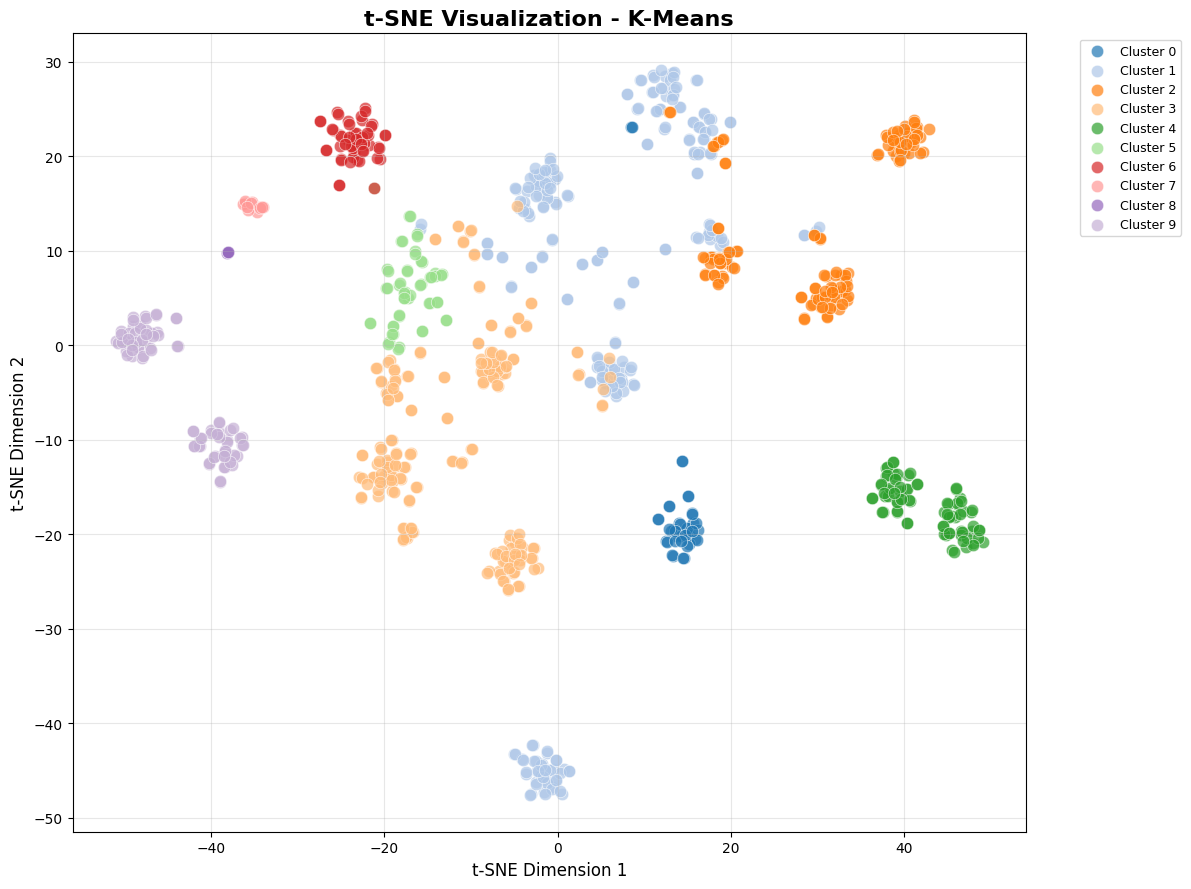

In [ ]:
from sklearn.cluster import KMeans

def kmeans_clustering(emb_dict, n_clusters=10, output_dir='/content/clustered_results'):
    """K-Means clustering with t-SNE visualization"""
    X = np.array(list(emb_dict.values()))

    print(f"\n{'='*60}")
    print("🔵 K-MEANS CLUSTERING")
    print(f"{'='*60}")

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    metrics = evaluate_clustering(X, labels, 'K-Means')
    save_clusters_to_folders(emb_dict, labels, output_dir, 'kmeans')

    # t-SNE visualization
    plot_tsne_scatter(X, labels, 'K-Means')

    return labels, metrics

# Run K-Means
labels_kmeans, metrics_kmeans = kmeans_clustering(emb_dict, n_clusters=10)


2. Fuzzy C-Means Clustering with t-SNE



🟡 FUZZY C-MEANS CLUSTERING

📊 Fuzzy C-Means Results:
  Clusters: 4
  Outliers: 0
  Silhouette Score: -0.0862
  Davies-Bouldin Index: 2.5835
  Calinski-Harabasz Index: 34.64
✅ Saved clusters to: /content/clustered_results/fuzzy_cmeans
  Fuzzy Partition Coefficient: 0.1000

🔄 Computing t-SNE for Fuzzy C-Means...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


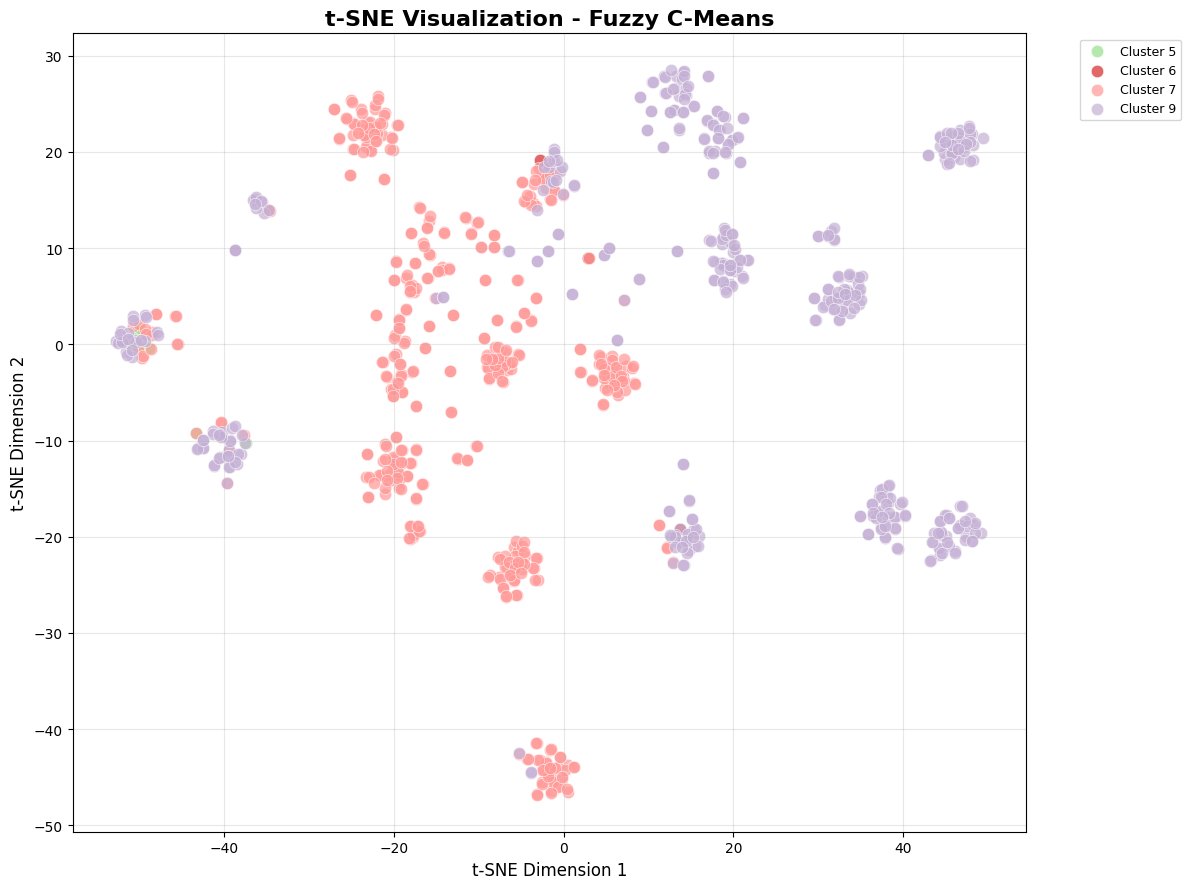

In [ ]:
import skfuzzy as fuzz

def fuzzy_cmeans_clustering(emb_dict, n_clusters=10, output_dir='/content/clustered_results'):
    """Fuzzy C-Means clustering with t-SNE visualization"""
    X = np.array(list(emb_dict.values()))

    print(f"\n{'='*60}")
    print("🟡 FUZZY C-MEANS CLUSTERING")
    print(f"{'='*60}")

    X_T = X.T

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_T, c=n_clusters, m=2, error=0.005, maxiter=1000, init=None
    )

    labels = np.argmax(u, axis=0)

    metrics = evaluate_clustering(X, labels, 'Fuzzy C-Means')
    save_clusters_to_folders(emb_dict, labels, output_dir, 'fuzzy_cmeans')

    print(f"  Fuzzy Partition Coefficient: {fpc:.4f}")

    # t-SNE visualization
    plot_tsne_scatter(X, labels, 'Fuzzy C-Means')

    return labels, metrics

# Run Fuzzy C-Means
labels_fcm, metrics_fcm = fuzzy_cmeans_clustering(emb_dict, n_clusters=10)


3. Gaussian Mixture Model with t-SNE



🟢 GAUSSIAN MIXTURE MODEL

📊 Gaussian Mixture Results:
  Clusters: 10
  Outliers: 0
  Silhouette Score: 0.2060
  Davies-Bouldin Index: 2.2066
  Calinski-Harabasz Index: 52.25
✅ Saved clusters to: /content/clustered_results/gaussian_mixture
  BIC Score: 22471503.79
  AIC Score: 450879.31

🔄 Computing t-SNE for Gaussian Mixture Model...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


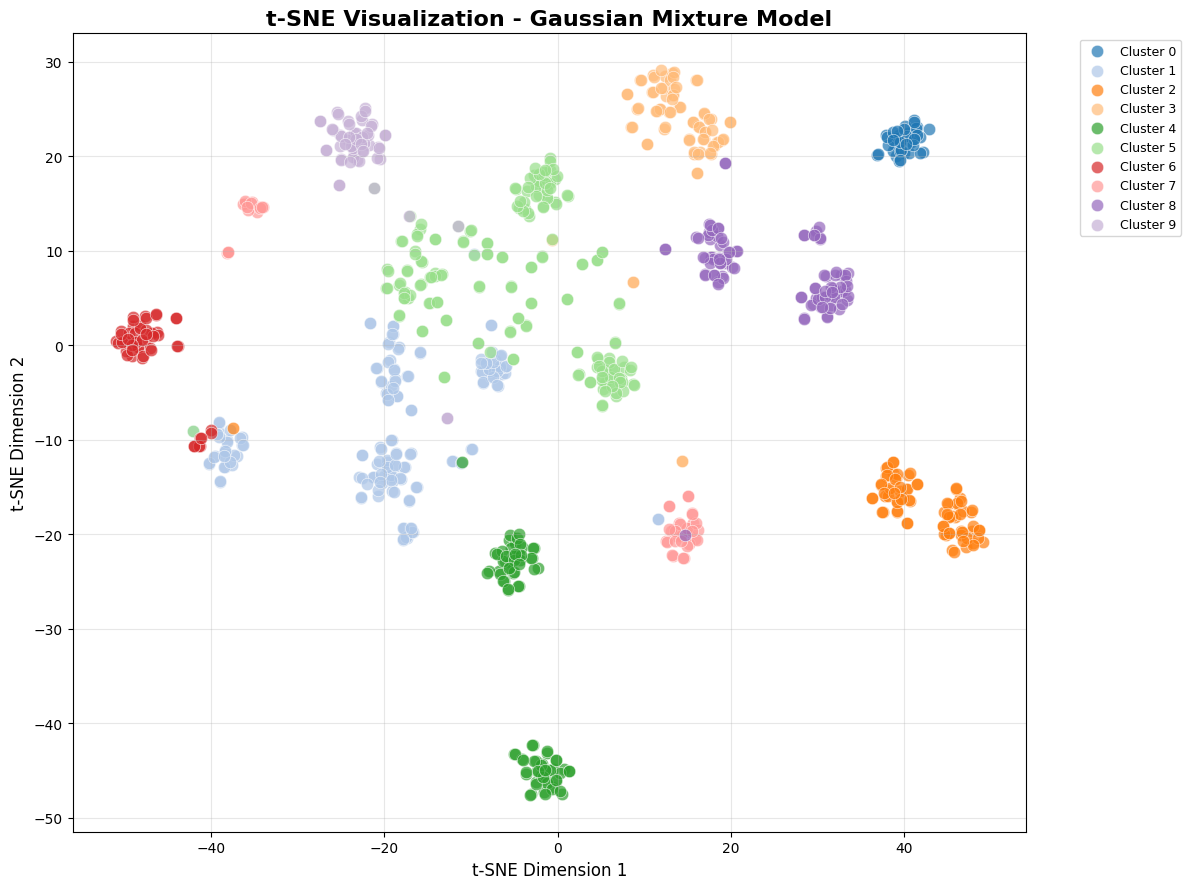

In [ ]:
from sklearn.mixture import GaussianMixture

def gmm_clustering(emb_dict, n_components=10, output_dir='/content/clustered_results'):
    """Gaussian Mixture Model clustering with t-SNE visualization"""
    X = np.array(list(emb_dict.values()))

    print(f"\n{'='*60}")
    print("🟢 GAUSSIAN MIXTURE MODEL")
    print(f"{'='*60}")

    gmm = GaussianMixture(n_components=n_components, covariance_type='full',
                          random_state=42, max_iter=100)
    labels = gmm.fit_predict(X)

    metrics = evaluate_clustering(X, labels, 'Gaussian Mixture')
    save_clusters_to_folders(emb_dict, labels, output_dir, 'gaussian_mixture')

    print(f"  BIC Score: {gmm.bic(X):.2f}")
    print(f"  AIC Score: {gmm.aic(X):.2f}")

    # t-SNE visualization
    plot_tsne_scatter(X, labels, 'Gaussian Mixture Model')

    return labels, metrics

# Run GMM
labels_gmm, metrics_gmm = gmm_clustering(emb_dict, n_components=10)


4. ANN-Based Clustering (SOM) with t-SNE



🔴 ANN-BASED CLUSTERING (SOM)

📊 SOM (ANN) Results:
  Clusters: 24
  Outliers: 0
  Silhouette Score: 0.2882
  Davies-Bouldin Index: 1.9764
  Calinski-Harabasz Index: 44.66
✅ Saved clusters to: /content/clustered_results/ann_som

🔄 Computing t-SNE for SOM (ANN-Based)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


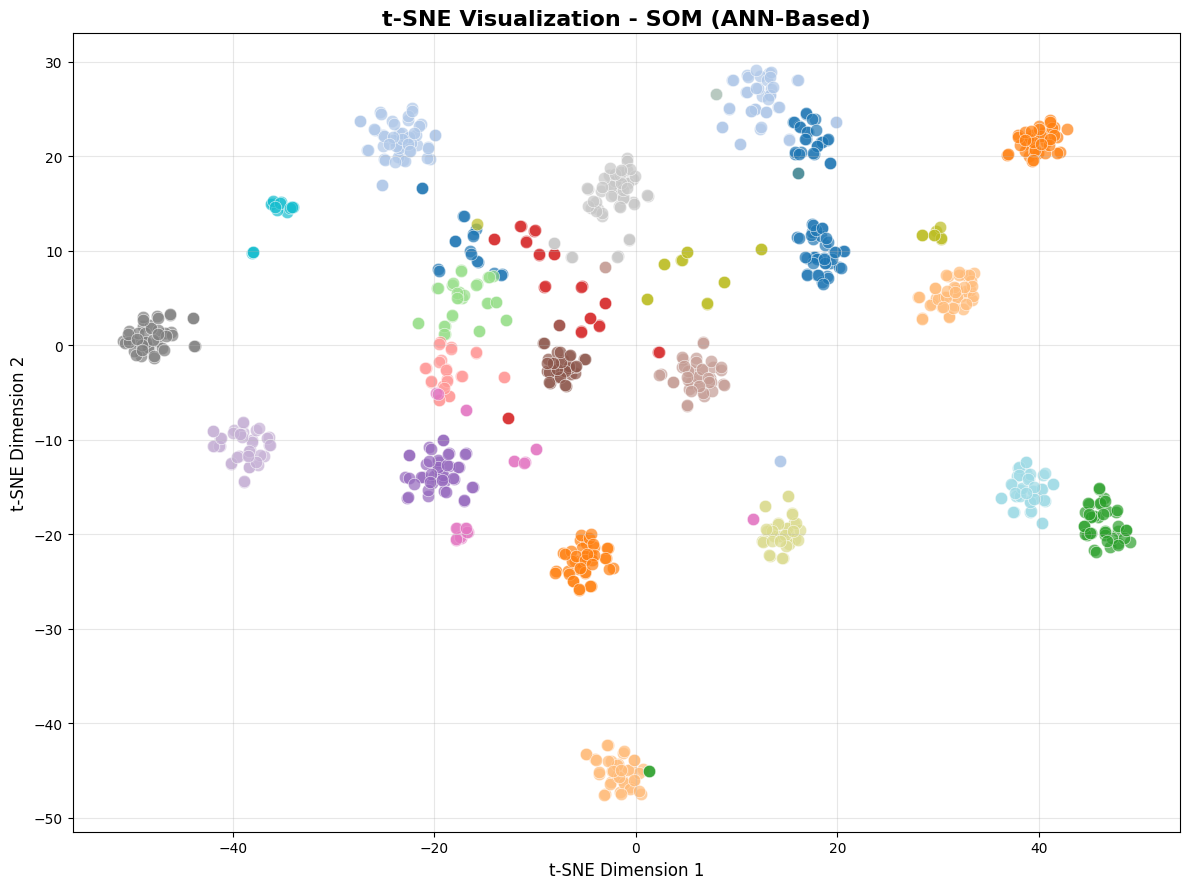

In [ ]:
from minisom import MiniSom

def som_clustering(emb_dict, grid_size=5, output_dir='/content/clustered_results'):
    """Self-Organizing Map (SOM) - ANN-based clustering with t-SNE visualization"""
    X = np.array(list(emb_dict.values()))

    print(f"\n{'='*60}")
    print("🔴 ANN-BASED CLUSTERING (SOM)")
    print(f"{'='*60}")

    som = MiniSom(grid_size, grid_size, X.shape[1], sigma=1.0, learning_rate=0.5,
                  neighborhood_function='gaussian', random_seed=42)
    som.train_random(X, 1000)

    labels = np.array([som.winner(x)[0] * grid_size + som.winner(x)[1] for x in X])

    metrics = evaluate_clustering(X, labels, 'SOM (ANN)')
    save_clusters_to_folders(emb_dict, labels, output_dir, 'ann_som')

    # t-SNE visualization
    plot_tsne_scatter(X, labels, 'SOM (ANN-Based)')

    return labels, metrics

# Run SOM
labels_som, metrics_som = som_clustering(emb_dict, grid_size=5)


5. Agglomerative Hierarchical with t-SNE



🟣 AGGLOMERATIVE HIERARCHICAL CLUSTERING

📊 Agglomerative Results:
  Clusters: 3
  Outliers: 0
  Silhouette Score: 0.7285
  Davies-Bouldin Index: 1.0113
  Calinski-Harabasz Index: 46.12
✅ Saved clusters to: /content/clustered_results/agglomerative

🔄 Computing t-SNE for Agglomerative Hierarchical...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


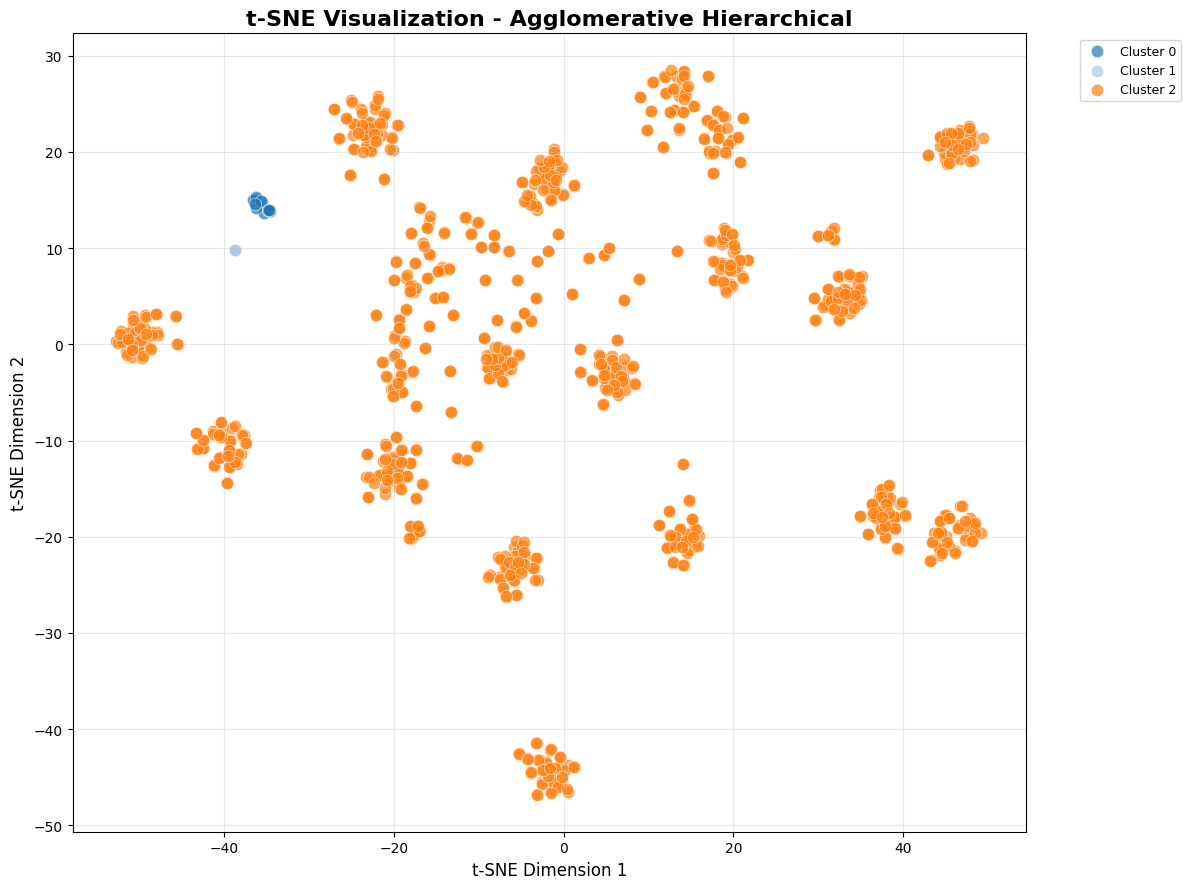

In [ ]:
from sklearn.cluster import AgglomerativeClustering

def agglomerative_clustering(emb_dict, distance_threshold=0.5, output_dir='/content/clustered_results'):
    """Agglomerative Hierarchical clustering with t-SNE visualization"""
    X = np.array(list(emb_dict.values()))

    print(f"\n{'='*60}")
    print("🟣 AGGLOMERATIVE HIERARCHICAL CLUSTERING")
    print(f"{'='*60}")

    agglo = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=distance_threshold,
        linkage='average',
        metric='cosine'
    )
    labels = agglo.fit_predict(X)

    metrics = evaluate_clustering(X, labels, 'Agglomerative')
    save_clusters_to_folders(emb_dict, labels, output_dir, 'agglomerative')

    # t-SNE visualization
    plot_tsne_scatter(X, labels, 'Agglomerative Hierarchical')

    return labels, metrics

# Run Agglomerative
labels_agglo, metrics_agglo = agglomerative_clustering(emb_dict, distance_threshold=0.5)


6. Spectral Clustering with t-SNE



🟠 SPECTRAL CLUSTERING

📊 Spectral Results:
  Clusters: 10
  Outliers: 0
  Silhouette Score: 0.2316
  Davies-Bouldin Index: 2.0198
  Calinski-Harabasz Index: 59.56
✅ Saved clusters to: /content/clustered_results/spectral

🔄 Computing t-SNE for Spectral Clustering...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


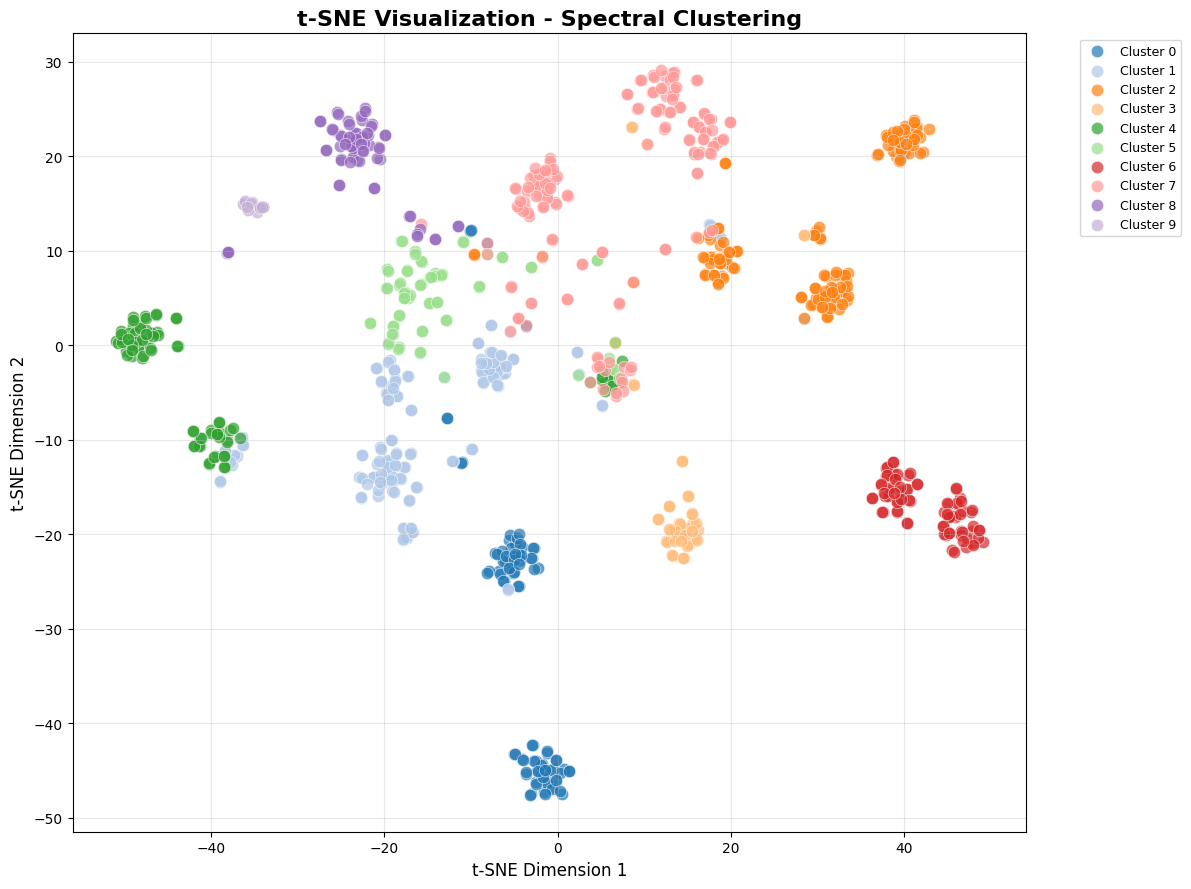

In [ ]:
from sklearn.cluster import SpectralClustering

def spectral_clustering(emb_dict, n_clusters=10, output_dir='/content/clustered_results'):
    """Spectral clustering with t-SNE visualization"""
    X = np.array(list(emb_dict.values()))

    print(f"\n{'='*60}")
    print("🟠 SPECTRAL CLUSTERING")
    print(f"{'='*60}")

    spectral = SpectralClustering(
        n_clusters=n_clusters,
        affinity='cosine',
        assign_labels='discretize',
        random_state=42
    )
    labels = spectral.fit_predict(X)

    metrics = evaluate_clustering(X, labels, 'Spectral')
    save_clusters_to_folders(emb_dict, labels, output_dir, 'spectral')

    # t-SNE visualization
    plot_tsne_scatter(X, labels, 'Spectral Clustering')

    return labels, metrics

# Run Spectral
labels_spectral, metrics_spectral = spectral_clustering(emb_dict, n_clusters=10)


7. DBSCAN Clustering with t-SNE



⚫ DBSCAN CLUSTERING

📊 DBSCAN Results:
  Clusters: 1
  Outliers: 0
  Silhouette Score: nan
  Davies-Bouldin Index: nan
  Calinski-Harabasz Index: nan
✅ Saved clusters to: /content/clustered_results/dbscan

🔄 Computing t-SNE for DBSCAN...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


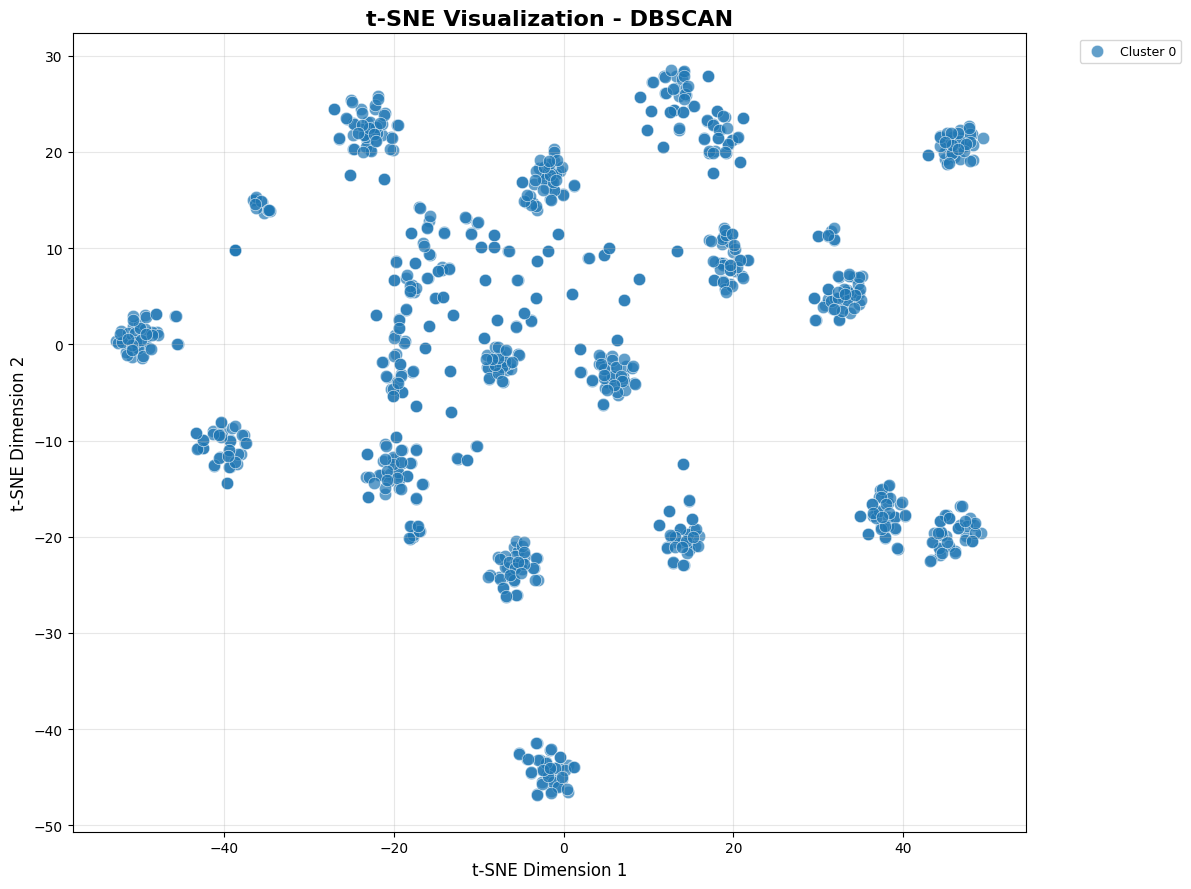

In [ ]:
from sklearn.cluster import DBSCAN

def dbscan_clustering(emb_dict, eps=0.5, min_samples=3, output_dir='/content/clustered_results'):
    """DBSCAN clustering with t-SNE visualization"""
    X = np.array(list(emb_dict.values()))

    print(f"\n{'='*60}")
    print("⚫ DBSCAN CLUSTERING")
    print(f"{'='*60}")

    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
    labels = dbscan.fit_predict(X)

    metrics = evaluate_clustering(X, labels, 'DBSCAN')
    save_clusters_to_folders(emb_dict, labels, output_dir, 'dbscan')

    # t-SNE visualization
    plot_tsne_scatter(X, labels, 'DBSCAN')

    return labels, metrics

# Run DBSCAN
labels_dbscan, metrics_dbscan = dbscan_clustering(emb_dict, eps=0.5, min_samples=3)


comparison summary


In [ ]:
def compare_all_algorithms(all_metrics):
    """Generate comparison table"""
    print("\n" + "="*100)
    print("📊 CLUSTERING ALGORITHMS COMPARISON")
    print("="*100)

    print(f"{'Algorithm':<25} {'Clusters':>10} {'Outliers':>10} {'Silhouette':>12} {'DBI':>10} {'CHI':>15}")
    print("-"*100)

    for m in all_metrics:
        print(f"{m['algorithm']:<25} {m['n_clusters']:>10} {m['n_outliers']:>10} "
              f"{m['silhouette']:>12.4f} {m['davies_bouldin']:>10.4f} {m['calinski_harabasz']:>15.2f}")

    print("="*100)

    # Find best by silhouette
    valid_metrics = [m for m in all_metrics if not np.isnan(m['silhouette'])]
    if valid_metrics:
        best = max(valid_metrics, key=lambda x: x['silhouette'])
        print(f"\n🏆 Best Algorithm (by Silhouette Score): {best['algorithm']} ({best['silhouette']:.4f})")

# Collect all results
all_metrics = [
    metrics_kmeans,
    metrics_fcm,
    metrics_gmm,
    metrics_som,
    metrics_agglo,
    metrics_spectral,
    metrics_dbscan
]

compare_all_algorithms(all_metrics)

print(f"\n✅ All clustered images saved to: {output_base}")



📊 CLUSTERING ALGORITHMS COMPARISON
Algorithm                   Clusters   Outliers   Silhouette        DBI             CHI
----------------------------------------------------------------------------------------------------
K-Means                           10          0       0.2250     1.8808           65.35
Fuzzy C-Means                      4          0      -0.0862     2.5835           34.64
Gaussian Mixture                  10          0       0.2060     2.2066           52.25
SOM (ANN)                         24          0       0.2882     1.9764           44.66
Agglomerative                      3          0       0.7285     1.0113           46.12
Spectral                          10          0       0.2316     2.0198           59.56
DBSCAN                             1          0          nan        nan             nan

🏆 Best Algorithm (by Silhouette Score): Agglomerative (0.7285)

✅ All clustered images saved to: /content/clustered_results
